# Mask Inter & Intra Variability

In [ ]:
!git clone https://github.com/UCT-Advanced-Image-Analysis/semester-project-2026.git

fatal: destination path 'semester-project-2026' already exists and is not an empty directory.


In [ ]:
# The only extra install you might need
!pip install pingouin -q

In [ ]:


import pandas as pd
import pingouin as pg
from sklearn.metrics import cohen_kappa_score

In [ ]:
import glob
import os

search_path = '/content/semester-project-2026/images'
pattern = os.path.join(search_path, '**', 'student_*.csv')

found_files = glob.glob(pattern, recursive=True)

if found_files:
    print("Found 'student_*.csv' files:")
    for file_path in found_files:
        print(file_path)
else:
    print("No 'student_*.csv' files found in the specified path.")

Found 'student_*.csv' files:
/content/semester-project-2026/images/student_10/student_10_counts.csv
/content/semester-project-2026/images/student_03/student_03_counts.csv
/content/semester-project-2026/images/student_04/student_04_counts.csv
/content/semester-project-2026/images/student_06/student_06_counts.csv
/content/semester-project-2026/images/student_07/student_07_counts.csv
/content/semester-project-2026/images/student_09/student_09_counts.csv
/content/semester-project-2026/images/student_08/student_08_counts.csv
/content/semester-project-2026/images/student_05/student_05_counts.csv
/content/semester-project-2026/images/student_02/student_02_counts.csv


Load CSV

In [ ]:
import pandas as pd
import re
import os

data = []
for file_path in found_files:
    filename = os.path.basename(file_path)
    match = re.search(r'student_(\d+)_counts\.csv', filename)
    if match:
        student_number = match.group(1)
        data.append({'student_number': student_number, 'path': file_path})

student_df = pd.DataFrame(data)
display(student_df.head())

,student_number,path
0,10,/content/semester-project-2026/images/student_...
1,03,/content/semester-project-2026/images/student_...
2,04,/content/semester-project-2026/images/student_...
3,06,/content/semester-project-2026/images/student_...
4,07,/content/semester-project-2026/images/student_...


Load file mapping from blind file mixing

In [ ]:
url = 'https://github.com/UCT-Advanced-Image-Analysis/semester-project-2026-eval/raw/refs/heads/main/tables/image_mapping_v2.csv'
image_mapping_df = pd.read_csv(url)
display(image_mapping_df.head())

,original_path,student_folder,new_filename,image_type
0,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_5.tif,calibration
1,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_13.tif,calibration
2,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_14.tif,calibration
3,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_8.tif,calibration
4,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_11.tif,duplicate


In [ ]:
image_mapping_df['original_filename'] = image_mapping_df['original_path'].apply(lambda x: x.split('/')[-1].replace('.tif', ''))
display(image_mapping_df.head())

,original_path,student_folder,new_filename,image_type,original_filename
0,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_5.tif,calibration,9GRAY_015-cropped
1,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_13.tif,calibration,16GRAY_045-cropped
2,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_14.tif,calibration,4GRAY_000-cropped
3,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_8.tif,calibration,1GRAY_030-cropped
4,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_11.tif,duplicate,12GRAY_015-cropped


Load numbers from correct images

In [ ]:
student_dataframes = {}

for index, row in student_df.iterrows():
    student_number = row['student_number']
    file_path = row['path']

    # Load the CSV file, using ';' as a separator
    df_student = pd.read_csv(file_path, sep=';', header=0, index_col=None, encoding='utf-8')

    # Add the 'student_folder' column
    df_student['student_folder'] = 'student_' + student_number

    # Store the DataFrame in the dictionary
    student_dataframes[student_number] = df_student


print(f"Loaded data for {len(student_dataframes)} students.")

# Display the head of one of the student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Loaded data for 9 students.

Displaying head for student 10:


,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder
0,img_01,60,54,47,58,58,64,NaN,student_10
1,img_02,77,59,57,80,80,83,NaN,student_10
2,img_03,54,37,28,49,49,56,NaN,student_10
3,img_04,42,38,34,42,42,45,NaN,student_10
4,img_05,73,49,45,52,52,73,NaN,student_10


In [ ]:
import re

for student_number, df_student in student_dataframes.items():
    # Standardize image_name to match the format in image_mapping_df (e.g., 'img_1.tif' instead of 'img_01.tif')
    # First, ensure it's a string and remove any existing '.tif' for consistent processing
    df_student['image_name'] = df_student['image_name'].astype(str).str.replace('\.tif$', '', regex=True)
    # Then, remove leading zeros from the numeric part of the image name
    df_student['image_name'] = df_student['image_name'].apply(lambda x: re.sub(r'img_0*(\d+)$', r'img_\1', x)) + '.tif'
    student_dataframes[student_number] = df_student

print("Standardized 'image_name' column formatting in all student dataframes.")

# Display the head of one of the updated student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for standardized student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Standardized 'image_name' column formatting in all student dataframes.

Displaying head for standardized student 10:


<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:6: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_27870/2773219164.py:6: SyntaxWarning: invalid escape sequence '\.'
  df_student['image_name'] = df_student['image_name'].astype(str).str.replace('\.tif$', '', regex=True)


,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder
0,img_1.tif,60,54,47,58,58,64,NaN,student_10
1,img_2.tif,77,59,57,80,80,83,NaN,student_10
2,img_3.tif,54,37,28,49,49,56,NaN,student_10
3,img_4.tif,42,38,34,42,42,45,NaN,student_10
4,img_5.tif,73,49,45,52,52,73,NaN,student_10


In [ ]:
for student_number, df_student in student_dataframes.items():
    # Merge with image_mapping_df using 'student_folder' and 'image_name' (from df_student)
    # and 'new_filename' (from image_mapping_df)
    merged_df = pd.merge(
        df_student,
        image_mapping_df[['student_folder', 'new_filename', 'image_type', 'original_filename']],
        left_on=['student_folder', 'image_name'],
        right_on=['student_folder', 'new_filename'],
        how='left'
    )
    # Drop the redundant 'new_filename' column from the merge if it exists
    # Note: 'new_filename' is from image_mapping_df, which we don't want to keep in the final student_df
    merged_df = merged_df.drop(columns=['new_filename'])
    student_dataframes[student_number] = merged_df

print("Updated student_dataframes with image_type and original_filename.")

# Display the head of one of the updated student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for updated student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Updated student_dataframes with image_type and original_filename.

Displaying head for updated student 10:


,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename
0,img_1.tif,60,54,47,58,58,64,NaN,student_10,unique_random,19GRAY_015-cropped
1,img_2.tif,77,59,57,80,80,83,NaN,student_10,unique_random,14GRAY_000-cropped
2,img_3.tif,54,37,28,49,49,56,NaN,student_10,unique_random,18GRAY_030-cropped
3,img_4.tif,42,38,34,42,42,45,NaN,student_10,unique_random,11GRAY_030-cropped
4,img_5.tif,73,49,45,52,52,73,NaN,student_10,unique_random,10GRAY_030-cropped


In [ ]:
df_student = student_dataframes[first_student_key]
df_student[df_student['image_type']=='calibration']

,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename
5,img_6.tif,72,50,48,58,58,71,NaN,student_10,calibration,9GRAY_015-cropped
6,img_7.tif,55,42,37,46,46,55,NaN,student_10,calibration,1GRAY_030-cropped
8,img_9.tif,70,64,60,73,73,75,NaN,student_10,calibration,4GRAY_000-cropped
12,img_13.tif,58,35,33,43,43,51,NaN,student_10,calibration,16GRAY_045-cropped


In [ ]:
import pandas as pd

# Concatenate all student dataframes into one big table
all_students_df = pd.concat(student_dataframes.values(), ignore_index=True)

# Add a new column 'student' as a duplicate of 'student_folder'
all_students_df['student'] = all_students_df['student_folder']

# Extract 'xx' from 'student_folder'
xx = all_students_df['student_folder'].str.extract(r'student_(\d+)').iloc[:, 0]

# Extract 'yy' from 'image_name' (assuming image_name always ends with .tif)
yy = all_students_df['image_name'].str.extract(r'img_(\d+)\.tif').iloc[:, 0]

# Create the new 'path' column
all_students_df['path'] = 'student_' + xx + '/img_' + yy + '.tiff'

# Display the head of the new big table
all_students_df.head()

,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename,script_watershed,student,path
0,img_1.tif,60.0,54.0,47.0,58.0,58.0,64.0,NaN,student_10,unique_random,19GRAY_015-cropped,NaN,student_10,student_10/img_1.tiff
1,img_2.tif,77.0,59.0,57.0,80.0,80.0,83.0,NaN,student_10,unique_random,14GRAY_000-cropped,NaN,student_10,student_10/img_2.tiff
2,img_3.tif,54.0,37.0,28.0,49.0,49.0,56.0,NaN,student_10,unique_random,18GRAY_030-cropped,NaN,student_10,student_10/img_3.tiff
3,img_4.tif,42.0,38.0,34.0,42.0,42.0,45.0,NaN,student_10,unique_random,11GRAY_030-cropped,NaN,student_10,student_10/img_4.tiff
4,img_5.tif,73.0,49.0,45.0,52.0,52.0,73.0,NaN,student_10,unique_random,10GRAY_030-cropped,NaN,student_10,student_10/img_5.tiff


In [ ]:
all_students_df.to_csv('all_students_df.csv', index=False)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filter for duplicate images
duplicates_df = all_students_df[all_students_df['image_type'] == 'duplicate'].copy()

duplicates_df

,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename,script_watershed,student,path
7,img_8.tif,81.0,70.0,71.0,82.0,82.0,83.0,NaN,student_10,duplicate,12GRAY_000-cropped,NaN,student_10,student_10/img_8.tiff
14,img_15.tif,80.0,70.0,71.0,82.0,82.0,83.0,NaN,student_10,duplicate,12GRAY_000-cropped,NaN,student_10,student_10/img_15.tiff
23,img_9.tif,55.0,35.0,45.0,NaN,51.0,NaN,NaN,student_03,duplicate,19GRAY_030-cropped,53.0,student_03,student_03/img_9.tiff
29,img_15.tif,55.0,35.0,45.0,NaN,51.0,NaN,NaN,student_03,duplicate,19GRAY_030-cropped,53.0,student_03,student_03/img_15.tiff
31,img_2.tif,69.0,45.0,46.0,NaN,59.0,63.0,NaN,student_04,duplicate,12GRAY_015-cropped,61.0,student_04,student_04/img_2.tiff
39,img_10.tif,77.0,50.0,52.0,NaN,67.0,63.0,NaN,student_04,duplicate,12GRAY_015-cropped,68.0,student_04,student_04/img_10.tiff
66,img_7.tif,114.0,54.0,44.0,NaN,61.0,95.0,NaN,student_07,duplicate,11GRAY_045-cropped,97.0,student_07,student_07/img_7.tiff
69,img_10.tif,109.0,51.0,44.0,NaN,61.0,95.0,NaN,student_07,duplicate,11GRAY_045-cropped,97.0,student_07,student_07/img_10.tiff
76,img_2.tif,79.0,41.0,42.0,NaN,60.0,73.0,NaN,student_09,duplicate,15GRAY_030-cropped,74.0,student_09,student_09/img_2.tiff
78,img_4.tif,79.0,41.0,42.0,NaN,60.0,73.0,NaN,student_09,duplicate,15GRAY_030-cropped,74.0,student_09,student_09/img_4.tiff


## Intra masks

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
import os

# --- Helper Functions ---

def load_and_binarize_mask(mask_path, target_size=None):
    """
    Loads a mask image, converts to grayscale, binarizes it, and optionally resizes.
    Returns a boolean numpy array and its original size, or (None, None) if loading fails.
    """
    if not os.path.exists(mask_path):
        # print(f"Mask file not found: {mask_path}") # Uncomment for debugging missing files
        return None, None
    try:
        mask_img = Image.open(mask_path).convert('L') # Ensure grayscale
        original_size = mask_img.size
        if target_size and mask_img.size != target_size:
            mask_img = mask_img.resize(target_size, Image.NEAREST)
        # Binarize: any non-zero pixel becomes True
        return (np.array(mask_img) > 0).astype(bool), original_size
    except Exception as e:
        print(f"Error loading mask {mask_path}: {e}")
        return None, None

def calculate_mask_metrics(pred_mask, gt_mask):
    """
    Calculates IoU, F1-Score, Accuracy, and Balanced Accuracy for two boolean masks.
    Assumes pred_mask and gt_mask are already binarized boolean numpy arrays
    of the same shape.
    """
    if pred_mask.shape != gt_mask.shape:
        raise ValueError("Prediction and Ground Truth masks must have the same shape for metric calculation.")

    pred_mask_flat = pred_mask.flatten()
    gt_mask_flat = gt_mask.flatten()

    intersection = np.sum(np.logical_and(pred_mask, gt_mask))
    union = np.sum(np.logical_or(pred_mask, gt_mask))
    iou = intersection / union if union != 0 else 0.0

    # F1-Score (Dice Coefficient)
    f1_score = (2 * intersection) / (np.sum(pred_mask) + np.sum(gt_mask)) if (np.sum(pred_mask) + np.sum(gt_mask)) != 0 else 0.0

    # For accuracy metrics, need TP, TN, FP, FN
    tp = np.sum(np.logical_and(pred_mask_flat, gt_mask_flat)) # True Positive
    tn = np.sum(np.logical_and(~pred_mask_flat, ~gt_mask_flat)) # True Negative
    fp = np.sum(np.logical_and(pred_mask_flat, ~gt_mask_flat)) # False Positive
    fn = np.sum(np.logical_and(~pred_mask_flat, gt_mask_flat)) # False Negative

    total_pixels = pred_mask_flat.size

    # Accuracy
    accuracy = (tp + tn) / total_pixels if total_pixels != 0 else 0.0

    # Balanced Accuracy
    sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0.0 # Recall
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0.0
    balanced_accuracy = (sensitivity + specificity) / 2

    return {
        'IoU': iou,
        'F1_Score': f1_score,
        'Accuracy': accuracy,
        'Balanced_Accuracy': balanced_accuracy,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
    }

# --- Prepare duplicates_df with necessary path columns and student_id ---

# Ensure base_repo_path is available
if 'base_repo_path' not in locals():
    base_repo_path = '/content/semester-project-2026/'

# Add 'student_id' column to duplicates_df for easier grouping
if 'student_id' not in duplicates_df.columns:
    duplicates_df['student_id'] = duplicates_df['student_folder'].str.replace('student_', '')

# Ensure duplicates_df has the necessary full path columns (if not already derived)
if 'gt_mask_full_path' not in duplicates_df.columns:
    duplicates_df['gt_mask_full_path'] = duplicates_df['path'].astype(str).apply(
        lambda x: os.path.join(base_repo_path, 'gt', x).replace('.tiff', '.tif')
    )
if 'label_map_full_path' not in duplicates_df.columns:
    duplicates_df['label_map_full_path'] = duplicates_df['path'].astype(str).apply(
        lambda x: os.path.join(base_repo_path, 'labels', x).replace('.tiff', '.tif')
    )


# --- Comparison 1: Duplicate masks against each other for each student ---
print("\n--- Starting Duplicate Self-Comparison (Student Masks against each other) ---")
duplicate_self_comparison_results = []

grouped_duplicates_for_self_comp = duplicates_df.groupby(['student_id', 'original_filename'])

for (student_id, original_filename), group in grouped_duplicates_for_self_comp:
    label_map_paths = group['label_map_full_path'].tolist()

    if len(label_map_paths) > 1: # Only compare if there are actual duplicate submissions for this student/image
        loaded_masks_info = []
        # Attempt to load the first mask to establish a target size
        first_mask, first_size = load_and_binarize_mask(label_map_paths[0])
        if first_mask is None:
            print(f"Could not load first mask for student {student_id}, original {original_filename}. Skipping group.")
            continue
        loaded_masks_info.append({'path': label_map_paths[0], 'mask': first_mask})
        target_size = first_size

        # Load remaining masks, resizing to the target_size
        for path in label_map_paths[1:]:
            mask, _ = load_and_binarize_mask(path, target_size=target_size)
            if mask is not None:
                loaded_masks_info.append({'path': path, 'mask': mask})
            else:
                print(f"Warning: Could not load or resize mask {path} for student {student_id}, original {original_filename}.")

        if len(loaded_masks_info) < 2:
            print(f"Not enough valid masks for self-comparison for student {student_id}, original {original_filename}. Skipping.")
            continue

        # Perform pairwise comparison
        for i in range(len(loaded_masks_info)):
            for j in range(i + 1, len(loaded_masks_info)):
                mask1 = loaded_masks_info[i]['mask']
                mask2 = loaded_masks_info[j]['mask']

                metrics = calculate_mask_metrics(mask1, mask2)
                duplicate_self_comparison_results.append({
                    'student_id': student_id,
                    'original_filename': original_filename,
                    'comparison_type': 'student_duplicate_self',
                    'mask_path_1': loaded_masks_info[i]['path'],
                    'mask_path_2': loaded_masks_info[j]['path'],
                    **metrics
                })

duplicate_self_comparison_df = pd.DataFrame(duplicate_self_comparison_results)

if not duplicate_self_comparison_df.empty:
    print("\nDuplicate Self-Comparison Results:")
    display(duplicate_self_comparison_df.head())
    print("\nSummary Statistics for Duplicate Self-Comparison:")
    display(duplicate_self_comparison_df[['IoU', 'F1_Score', 'Accuracy', 'Balanced_Accuracy']].describe())
else:
    print("\nNo duplicate self-comparison results could be generated.")


# --- Comparison 2: Duplicate masks against ground truth mask for each student ---
print("\n--- Starting Duplicate vs. Ground Truth Comparison (Each Student Mask) ---")
duplicate_gt_comparison_results = []

for index, row in duplicates_df.iterrows():
    student_mask_path = row['label_map_full_path']
    gt_mask_path = row['gt_mask_full_path']
    original_filename = row['original_filename']
    student_id = row['student_id']

    gt_mask, gt_size = load_and_binarize_mask(gt_mask_path)
    if gt_mask is None:
        # print(f"GT mask not found or failed to load for {original_filename} (student {student_id}). Skipping.")
        continue

    student_mask, _ = load_and_binarize_mask(student_mask_path, target_size=gt_size) # Resize student mask to GT size
    if student_mask is None:
        # print(f"Student mask not found or failed to load for {original_filename} (student {student_id}). Skipping.")
        continue

    metrics = calculate_mask_metrics(student_mask, gt_mask)
    duplicate_gt_comparison_results.append({
        'student_id': student_id,
        'original_filename': original_filename,
        'comparison_type': 'student_duplicate_vs_gt',
        'student_mask_path': student_mask_path,
        **metrics
    })

duplicate_gt_comparison_df = pd.DataFrame(duplicate_gt_comparison_results)

# Add a column to differentiate between multiple duplicate submissions for the same image by the same student
duplicate_gt_comparison_df['duplicate_submission_idx'] = duplicate_gt_comparison_df.groupby(['student_id', 'original_filename']).cumcount() + 1

if not duplicate_gt_comparison_df.empty:
    print("\nDuplicate vs. Ground Truth Comparison Results:")
    display(duplicate_gt_comparison_df.head())
    print("\nSummary Statistics for Duplicate vs. Ground Truth Comparison:")
    display(duplicate_gt_comparison_df[['IoU', 'F1_Score', 'Accuracy', 'Balanced_Accuracy']].describe())
else:
    print("\nNo duplicate vs. ground truth comparison results generated.")


# --- Comparison 3: Union of duplicate masks against ground truth mask for each student ---
print("\n--- Starting Union of Duplicates vs. Ground Truth Comparison (Per Student) ---")
union_duplicates_gt_comparison_results = []

grouped_duplicates_for_union_comp = duplicates_df.groupby(['student_id', 'original_filename'])

for (student_id, original_filename), group in grouped_duplicates_for_union_comp:
    student_label_mask_paths = group['label_map_full_path'].tolist()
    gt_mask_path = group['gt_mask_full_path'].iloc[0] # GT path should be same for all entries of an original_filename

    gt_mask, gt_size = load_and_binarize_mask(gt_mask_path)
    if gt_mask is None:
        print(f"GT mask not found or failed to load for {original_filename} (student {student_id}). Skipping union comparison.")
        continue

    # Initialize union mask with all False (empty mask) with the same dimensions as GT
    union_mask = np.full(gt_size, False, dtype=bool)
    valid_student_masks_found = False

    for path in student_label_mask_paths:
        student_mask, _ = load_and_binarize_mask(path, target_size=gt_size) # Resize to GT size
        if student_mask is not None:
            union_mask = np.logical_or(union_mask, student_mask) # Compute union
            valid_student_masks_found = True
        else:
            print(f"Warning: Could not load student mask {path} for union calculation for student {student_id}, image {original_filename}.")

    if not valid_student_masks_found:
        print(f"No valid student masks found for union calculation for student {student_id}, image {original_filename}. Skipping.")
        continue

    metrics = calculate_mask_metrics(union_mask, gt_mask)
    union_duplicates_gt_comparison_results.append({
        'student_id': student_id,
        'original_filename': original_filename,
        'comparison_type': 'union_duplicates_vs_gt',
        **metrics
    })

union_duplicates_gt_comparison_df = pd.DataFrame(union_duplicates_gt_comparison_results)

if not union_duplicates_gt_comparison_df.empty:
    print("\nUnion of Duplicates vs. Ground Truth Comparison Results:")
    display(union_duplicates_gt_comparison_df.head())
    print("\nSummary Statistics for Union of Duplicates vs. Ground Truth Comparison:")
    display(union_duplicates_gt_comparison_df[['IoU', 'F1_Score', 'Accuracy', 'Balanced_Accuracy']].describe())
else:
    print("\nNo union of duplicates vs. ground truth comparison results generated.")


--- Starting Duplicate Self-Comparison (Student Masks against each other) ---
Could not load first mask for student 03, original 19GRAY_030-cropped. Skipping group.
Could not load first mask for student 04, original 12GRAY_015-cropped. Skipping group.
Could not load first mask for student 08, original 10GRAY_015-cropped. Skipping group.
Could not load first mask for student 10, original 12GRAY_000-cropped. Skipping group.

Duplicate Self-Comparison Results:


,student_id,original_filename,comparison_type,mask_path_1,mask_path_2,IoU,F1_Score,Accuracy,Balanced_Accuracy,TP,TN,FP,FN
0,02,12GRAY_015-cropped,student_duplicate_self,/content/semester-project-2026/labels/student_...,/content/semester-project-2026/labels/student_...,0.851714,0.919919,0.972694,0.962987,35387,184077,4239,1922
1,05,17GRAY_030-cropped,student_duplicate_self,/content/semester-project-2026/labels/student_...,/content/semester-project-2026/labels/student_...,0.799525,0.888596,0.971169,0.916756,25943,193177,1633,4872
2,07,11GRAY_045-cropped,student_duplicate_self,/content/semester-project-2026/labels/student_...,/content/semester-project-2026/labels/student_...,0.662240,0.796805,0.954455,0.865015,20148,195201,3470,6806
3,09,15GRAY_030-cropped,student_duplicate_self,/content/semester-project-2026/labels/student_...,/content/semester-project-2026/labels/student_...,0.801062,0.889544,0.976080,0.926833,21732,198496,1960,3437



Summary Statistics for Duplicate Self-Comparison:


,IoU,F1_Score,Accuracy,Balanced_Accuracy
count,4.000000,4.000000,4.000000,4.000000
mean,0.778635,0.873716,0.968599,0.917898
std,0.081297,0.053298,0.009650,0.040459
min,0.662240,0.796805,0.954455,0.865015
25%,0.765204,0.865648,0.966991,0.903821
50%,0.800293,0.889070,0.971931,0.921795
75%,0.813725,0.897138,0.973540,0.935871
max,0.851714,0.919919,0.976080,0.962987



--- Starting Duplicate vs. Ground Truth Comparison (Each Student Mask) ---

Duplicate vs. Ground Truth Comparison Results:


...

,IoU,F1_Score,Accuracy,Balanced_Accuracy
count,8.000000,8.000000,8.000000,8.000000
mean,0.739853,0.845440,0.959986,0.928381
std,0.121114,0.082758,0.023297,0.048438
min,0.563819,0.721079,0.923391,0.828811
25%,0.630567,0.773261,0.941651,0.911373
50%,0.788292,0.881329,0.968448,0.953855
75%,0.826755,0.905097,0.978033,0.959738
max,0.869532,0.930214,0.985432,0.963505



--- Starting Union of Duplicates vs. Ground Truth Comparison (Per Student) ---
No valid student masks found for union calculation for student 03, image 19GRAY_030-cropped. Skipping.
No valid student masks found for union calculation for student 04, image 12GRAY_015-cropped. Skipping.
No valid student masks found for union calculation for student 08, image 10GRAY_015-cropped. Skipping.
No valid student masks found for union calculation for student 10, image 12GRAY_000-cropped. Skipping.

Union of Duplicates vs. Ground Truth Comparison Results:


,student_id,original_filename,comparison_type,IoU,F1_Score,Accuracy,Balanced_Accuracy,TP,TN,FP,FN
0,02,12GRAY_015-cropped,union_duplicates_vs_gt,0.537812,0.699451,0.914890,0.952767,22345,184077,19203,0
1,05,17GRAY_030-cropped,union_duplicates_vs_gt,0.865898,0.928130,0.979683,0.964983,29599,191442,2849,1735
2,07,11GRAY_045-cropped,union_duplicates_vs_gt,0.805400,0.892212,0.969303,0.919052,28665,190034,1759,5167
3,09,15GRAY_030-cropped,union_duplicates_vs_gt,0.832747,0.908742,0.979559,0.980173,22963,198050,4166,446



Summary Statistics for Union of Duplicates vs. Ground Truth Comparison:


,IoU,F1_Score,Accuracy,Balanced_Accuracy
count,4.000000,4.000000,4.000000,4.000000
mean,0.760464,0.857134,0.960859,0.954244
std,0.150482,0.106142,0.031030,0.026002
min,0.537812,0.699451,0.914890,0.919052
25%,0.738503,0.844022,0.955700,0.944338
50%,0.819074,0.900477,0.974431,0.958875
75%,0.841035,0.913589,0.979590,0.968780
max,0.865898,0.928130,0.979683,0.980173



### Visualization: Duplicate Masks Against Each Other (Self-Comparison)



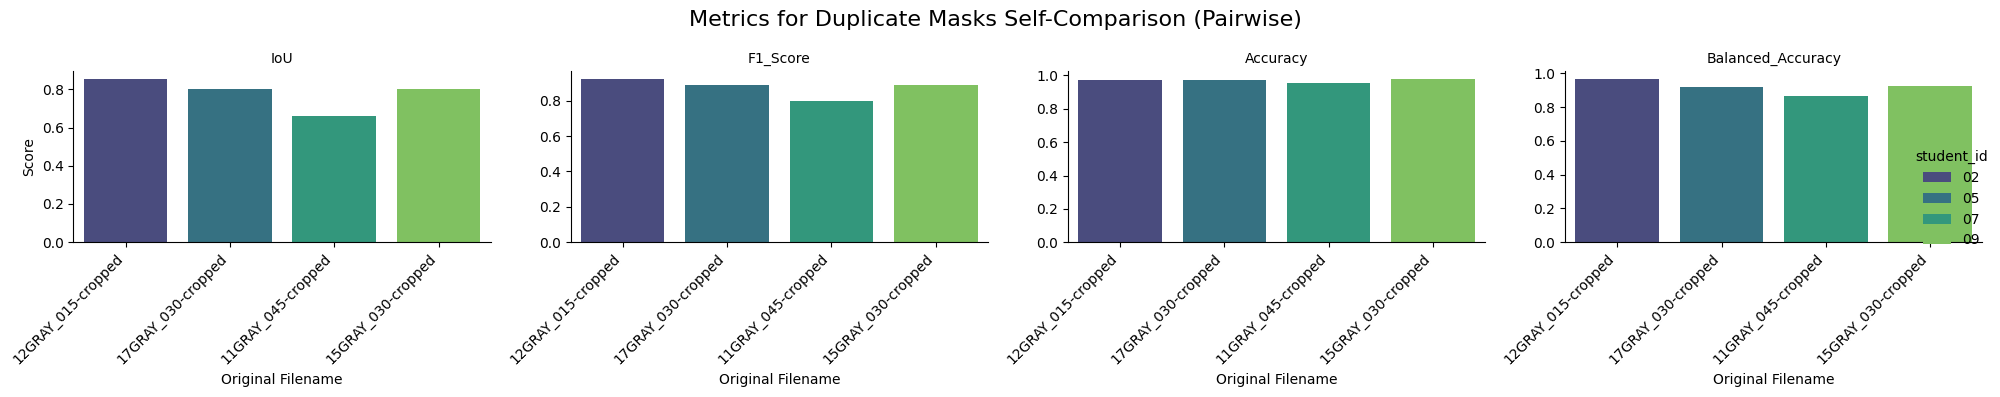

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualization 1: Duplicate masks against each other for each student ---
if not duplicate_self_comparison_df.empty:
    print("\n### Visualization: Duplicate Masks Against Each Other (Self-Comparison)\n")
    metrics_to_plot = ['IoU', 'F1_Score', 'Accuracy', 'Balanced_Accuracy']
    melted_self_comp_df = duplicate_self_comparison_df.melt(
        id_vars=['student_id', 'original_filename'],
        value_vars=metrics_to_plot,
        var_name='Metric',
        value_name='Score'
    )

    g = sns.catplot(
        data=melted_self_comp_df,
        x='original_filename',
        y='Score',
        hue='student_id',
        col='Metric',
        kind='bar',
        col_wrap=len(metrics_to_plot), # Display all metrics in one row
        height=4, aspect=1.2,
        palette='viridis',
        legend='auto',
        legend_out=True,
        errorbar=None,
        sharey=False
    )
    g.set_axis_labels("Original Filename", "Score")
    g.set_titles(col_template="{col_name}")
    g.set_xticklabels(rotation=45, ha='right')
    g.fig.suptitle('Metrics for Duplicate Masks Self-Comparison (Pairwise)', y=0.98, fontsize=16)
    #g.add_legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Add legend outside
    #g.fig.tight_layout(rect=[0, 0, 0.8, 0.98]) # Adjust tight_layout to make space for legend
    plt.tight_layout()
    plt.savefig('duplicate_masks_self_comparison.png')
    plt.show()
else:
    print("\nNo data available for 'Duplicate Masks Against Each Other' visualization.")


### Visualization: Individual Duplicate Masks Against Ground Truth



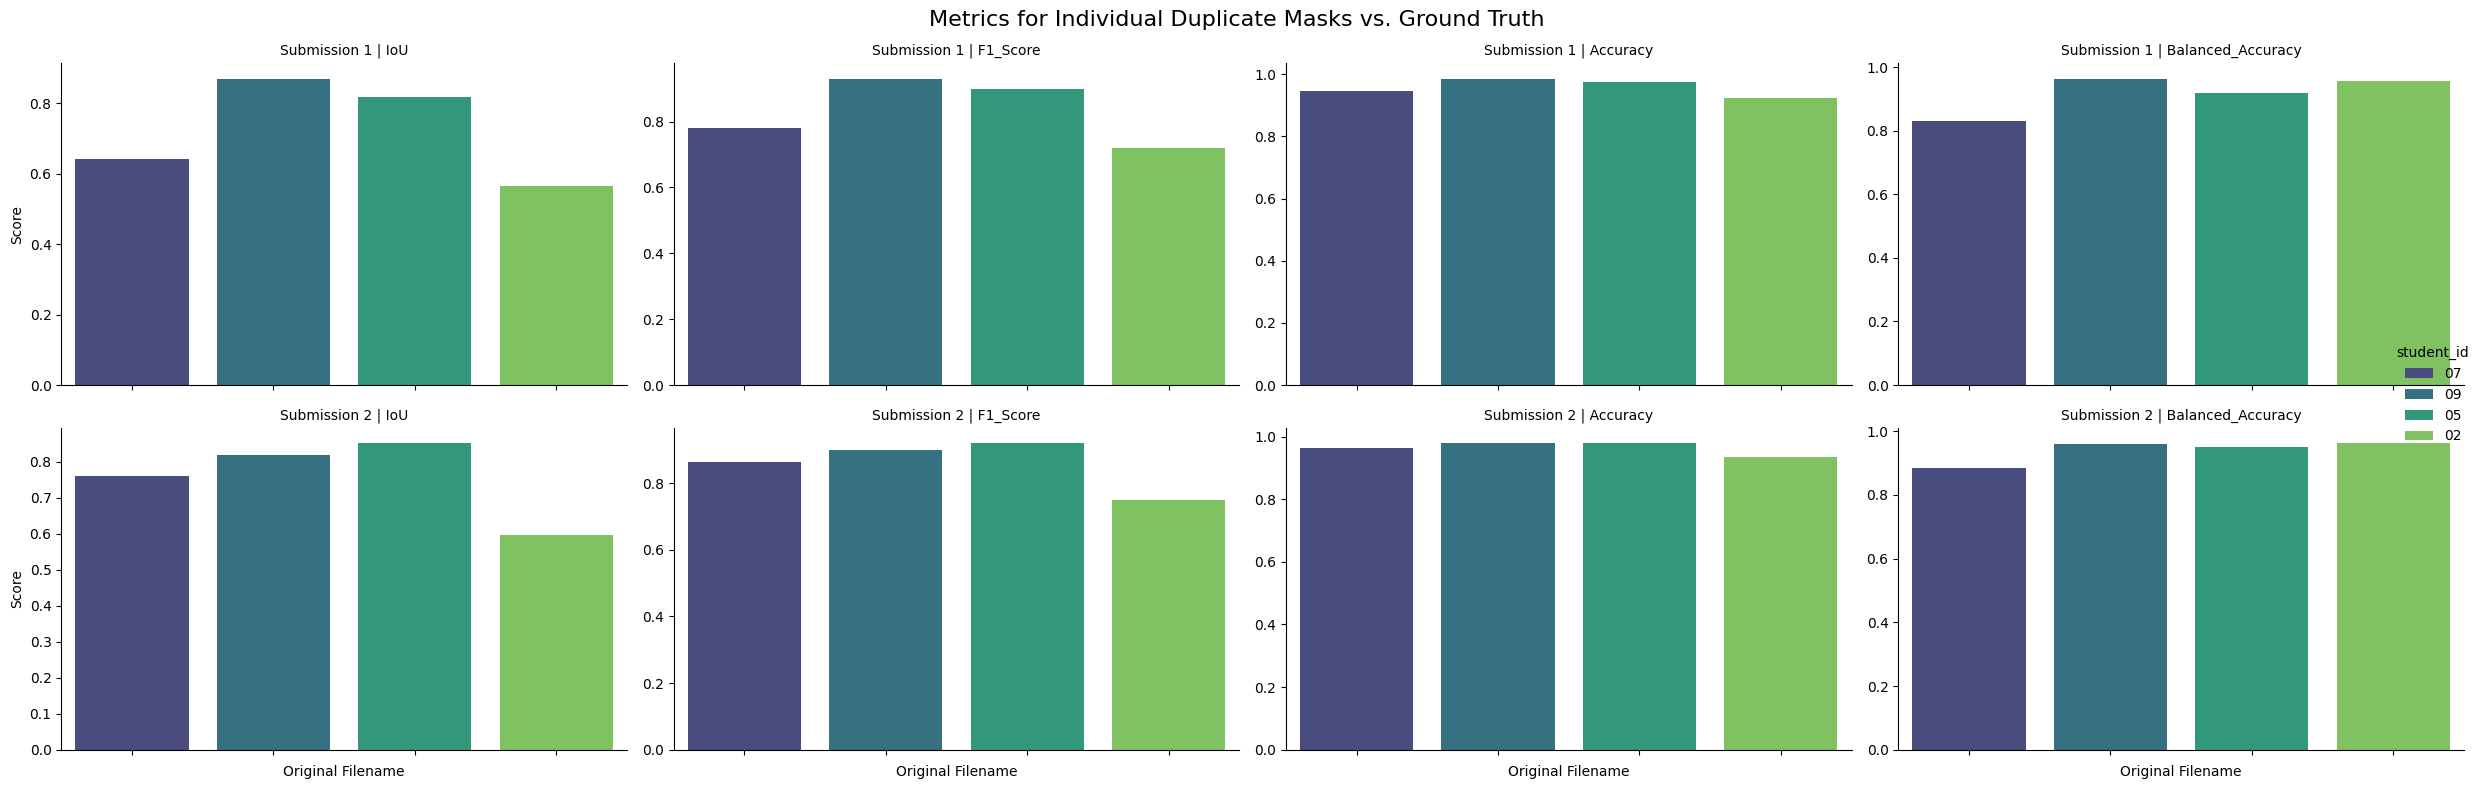

In [ ]:
# --- Visualization 2: Individual duplicate masks against the ground truth mask for each student ---
if not duplicate_gt_comparison_df.empty:
    print("\n### Visualization: Individual Duplicate Masks Against Ground Truth\n")
    metrics_to_plot = ['IoU', 'F1_Score', 'Accuracy', 'Balanced_Accuracy']
    melted_gt_comp_df = duplicate_gt_comparison_df.melt(
        id_vars=['student_id', 'original_filename', 'duplicate_submission_idx'],
        value_vars=metrics_to_plot,
        var_name='Metric',
        value_name='Score'
    )

    g = sns.catplot(
        data=melted_gt_comp_df,
        x='original_filename',
        y='Score',
        hue='student_id',
        col='Metric',
        row='duplicate_submission_idx',
        kind='bar',
        # Removed col_wrap as it's incompatible with 'row'
        height=4, aspect=1.5,
        palette='viridis',
        legend='auto',
        legend_out=True,
        errorbar=None,
        sharey=False
    )
    g.set_axis_labels("Original Filename", "Score")
    g.set_titles(row_template="Submission {row_name}", col_template="{col_name}")
    g.set_xticklabels(rotation=45, ha='right')
    g.fig.suptitle('Metrics for Individual Duplicate Masks vs. Ground Truth', y=0.98, fontsize=16)
    plt.tight_layout()
    #g.fig.tight_layout(rect=[0, 0, 1, 0.98])
    #g.add_legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig('individual_duplicate_masks_vs_gt.png')
    plt.show()
else:
    print("\nNo data available for 'Individual Duplicate Masks Against Ground Truth' visualization.")





### Visualization: Union of Duplicate Masks Against Ground Truth



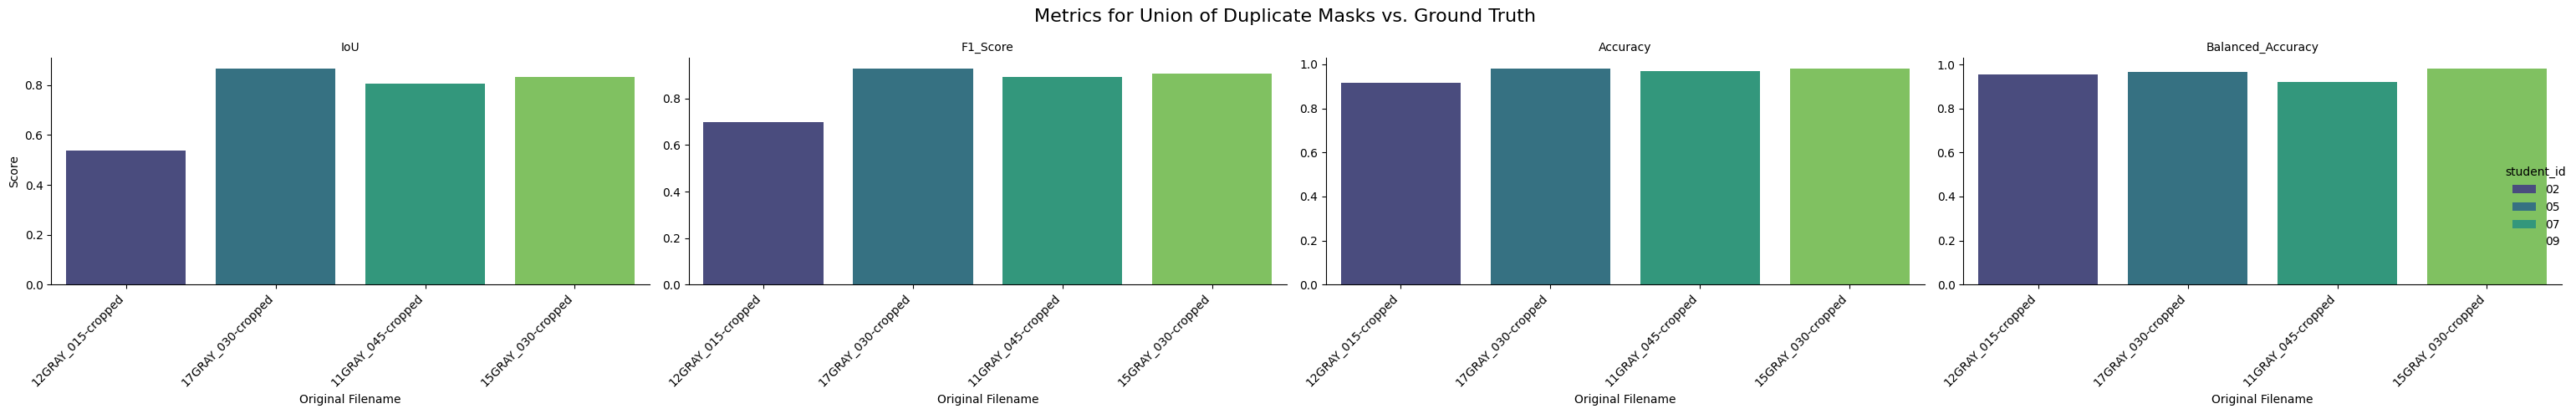

In [ ]:
# --- Visualization 3: Union of duplicate masks against the ground truth mask for each student ---
if not union_duplicates_gt_comparison_df.empty:
    print("\n### Visualization: Union of Duplicate Masks Against Ground Truth\n")
    metrics_to_plot = ['IoU', 'F1_Score', 'Accuracy', 'Balanced_Accuracy']
    melted_union_gt_comp_df = union_duplicates_gt_comparison_df.melt(
        id_vars=['student_id', 'original_filename'],
        value_vars=metrics_to_plot,
        var_name='Metric',
        value_name='Score'
    )

    g = sns.catplot(
        data=melted_union_gt_comp_df,
        x='original_filename',
        y='Score',
        hue='student_id',
        col='Metric',
        kind='bar',
        col_wrap=len(metrics_to_plot), # Display all metrics in one row
        height=5, aspect=1.5,
        palette='viridis',
        legend='auto',
        legend_out=True,
        errorbar=None,
        sharey=False
    )
    g.set_axis_labels("Original Filename", "Score")
    g.set_titles(col_template="{col_name}")
    g.set_xticklabels(rotation=45, ha='right')
    g.fig.suptitle('Metrics for Union of Duplicate Masks vs. Ground Truth', y=0.98, fontsize=16)
    #g.fig.tight_layout(rect=[0, 0, 1, 0.98]) # Use g.fig.tight_layout
    # g.add_legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Removed duplicate legend
    plt.tight_layout()
    plt.savefig('union_of_duplicate_masks_vs_gt.png')
    plt.show()
else:
    print("\nNo data available for 'Union of Duplicate Masks Against Ground Truth' visualization.")

## Inter masks

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
import os

# Ensure base_repo_path is defined (it was defined in d88UGC8QS_n6)
base_repo_path = '/content/semester-project-2026/'

# Create a 'gt_mask_full_path' column in all_students_df
# This assumes GT masks are in a 'gt' subfolder and have a .tif extension
# while the 'path' column in all_students_df might have .tiff.
all_students_df['gt_mask_full_path'] = all_students_df['path'].astype(str).apply(
    lambda x: os.path.join(base_repo_path, 'gt', x).replace('.tiff', '.tif')
)
print("Added 'gt_mask_full_path' to all_students_df.")

# Create a 'label_map_full_path' column in all_students_df (moved from d88UGC8QS_n6)
# This assumes label maps are in a 'labels' subfolder and have a .tif extension
all_students_df['label_map_full_path'] = all_students_df['path'].astype(str).apply(
    lambda x: os.path.join(base_repo_path, 'labels', x).replace('.tiff', '.tif')
)
print("Added 'label_map_full_path' to all_students_df.") # Added print for clarity

# Filter for calibration images (as per previous cells, these are the ones with available masks for comparison)
calibration_comparison_df = all_students_df[all_students_df['image_type'] == 'calibration'].copy()

# Add 'student_id' column to calibration_comparison_df for easier grouping and plotting
calibration_comparison_df['student_id'] = calibration_comparison_df['student_folder'].str.replace('student_', '')

# List to store results
comparison_results = []

print(f"Starting mask comparison for {len(calibration_comparison_df)} calibration entries...")

for index, row in calibration_comparison_df.iterrows():
    student_mask_path = row['label_map_full_path']
    gt_mask_path = row['gt_mask_full_path']
    original_filename = row['original_filename']
    student_id = row['student'].replace('student_', '')

    student_mask = None
    gt_mask = None
    img_width, img_height = None, None

    # Load Student Mask
    if os.path.exists(student_mask_path):
        try:
            student_mask_img = Image.open(student_mask_path).convert('L') # Ensure grayscale
            img_width, img_height = student_mask_img.size
            student_mask = (np.array(student_mask_img) > 0).astype(bool) # Binarize: any non-zero pixel becomes True
        except Exception as e:
            print(f"Error loading student mask for {original_filename}, student {student_id}: {e}")
            continue # Skip this entry if student mask fails to load
    else:
        print(f"Student mask not found: {student_mask_path}")
        continue # Skip if student mask not found

    # Load GT Mask
    if os.path.exists(gt_mask_path):
        try:
            gt_mask_img = Image.open(gt_mask_path).convert('L') # Ensure grayscale
            # Resize GT mask to match student mask dimensions if necessary
            if gt_mask_img.size != (img_width, img_height):
                gt_mask_img = gt_mask_img.resize((img_width, img_height), Image.NEAREST)
            gt_mask = (np.array(gt_mask_img) > 0).astype(bool) # Binarize
        except Exception as e:
            print(f"Error loading GT mask for {original_filename}, student {student_id}: {e}")
            continue # Skip this entry if GT mask fails to load
    else:
        print(f"GT mask not found: {gt_mask_path}")
        continue # Skip if GT mask not found

    # Ensure both masks are boolean arrays for logical operations
    if student_mask is not None and gt_mask is not None:
        # Flatten masks for metrics that expect 1D arrays or pixel-wise comparison
        student_mask_flat = student_mask.flatten()
        gt_mask_flat = gt_mask.flatten()

        # Calculate IoU (Jaccard Index)
        intersection = np.sum(np.logical_and(student_mask, gt_mask))
        union = np.sum(np.logical_or(student_mask, gt_mask))
        iou = intersection / union if union != 0 else 0.0

        # Calculate F1-Score (Dice Coefficient)
        f1_score = (2 * intersection) / (np.sum(student_mask) + np.sum(gt_mask)) if (np.sum(student_mask) + np.sum(gt_mask)) != 0 else 0.0

        # For accuracy metrics, need TP, TN, FP, FN
        tp = np.sum(np.logical_and(student_mask_flat, gt_mask_flat)) # True Positive
        tn = np.sum(np.logical_and(~student_mask_flat, ~gt_mask_flat)) # True Negative
        fp = np.sum(np.logical_and(student_mask_flat, ~gt_mask_flat)) # False Positive
        fn = np.sum(np.logical_and(~student_mask_flat, gt_mask_flat)) # False Negative

        total_pixels = student_mask_flat.size

        # Accuracy
        accuracy = (tp + tn) / total_pixels if total_pixels != 0 else 0.0

        # Balanced Accuracy
        sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0.0 # Recall
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0.0
        balanced_accuracy = (sensitivity + specificity) / 2

        comparison_results.append({
            'original_filename': original_filename,
            'student_id': student_id,
            'IoU': iou,
            'F1_Score': f1_score,
            'Accuracy': accuracy,
            'Balanced_Accuracy': balanced_accuracy,
            'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
        })

mask_comparison_df = pd.DataFrame(comparison_results)

mask_comparison_df.to_csv('mask_comparison_results.csv', index=False)

if not mask_comparison_df.empty:
    print("\nMask Comparison Statistics (Student Label vs. Ground Truth):")
    display(mask_comparison_df.head())

    print("\nSummary Statistics for all metrics:")
    display(mask_comparison_df[['IoU', 'F1_Score', 'Accuracy', 'Balanced_Accuracy']].describe())
else:
    print("No mask comparison results could be generated.")

Added 'gt_mask_full_path' to all_students_df.
Added 'label_map_full_path' to all_students_df.
Starting mask comparison for 32 calibration entries...
Student mask not found: /content/semester-project-2026/labels/student_10/img_6.tif
Student mask not found: /content/semester-project-2026/labels/student_10/img_7.tif
Student mask not found: /content/semester-project-2026/labels/student_10/img_9.tif
Student mask not found: /content/semester-project-2026/labels/student_10/img_13.tif
Student mask not found: /content/semester-project-2026/labels/student_03/img_2.tif
Student mask not found: /content/semester-project-2026/labels/student_03/img_4.tif
Student mask not found: /content/semester-project-2026/labels/student_03/img_7.tif
Student mask not found: /content/semester-project-2026/labels/student_03/img_10.tif
Student mask not found: /content/semester-project-2026/labels/student_04/img_3.tif
Student mask not found: /content/semester-project-2026/labels/student_04/img_4.tif
Student mask not fo

,original_filename,student_id,IoU,F1_Score,Accuracy,Balanced_Accuracy,TP,TN,FP,FN
0,4GRAY_000-cropped,07,0.501582,0.668072,0.946947,0.758581,12046,201609,928,11042
1,16GRAY_045-cropped,07,0.470576,0.639989,0.954145,0.740441,9196,206083,518,9828
2,1GRAY_030-cropped,07,0.763478,0.865878,0.981567,0.890645,13425,208041,448,3711
3,9GRAY_015-cropped,07,0.716581,0.834894,0.969281,0.866074,17524,201170,620,6311
4,16GRAY_045-cropped,09,0.812688,0.896666,0.982019,0.956249,17602,203966,2635,1422



Summary Statistics for all metrics:


,IoU,F1_Score,Accuracy,Balanced_Accuracy
count,16.000000,16.000000,16.000000,16.000000
mean,0.696399,0.814216,0.962998,0.916330
std,0.129844,0.095073,0.022926,0.072008
min,0.470576,0.639989,0.910639,0.740441
25%,0.581787,0.735383,0.945801,0.904295
50%,0.774875,0.873113,0.973866,0.948480
75%,0.795595,0.886161,0.981576,0.963205
max,0.833940,0.909452,0.982746,0.974442


### Visualization of Mask Comparison Metrics

This visualization provides a clear overview of the agreement metrics (IoU, F1-Score, Accuracy, and Balanced Accuracy) between student-generated masks and ground truth for each calibration image. Each facet represents a different metric, with bars grouped by original filename and colored by student ID.

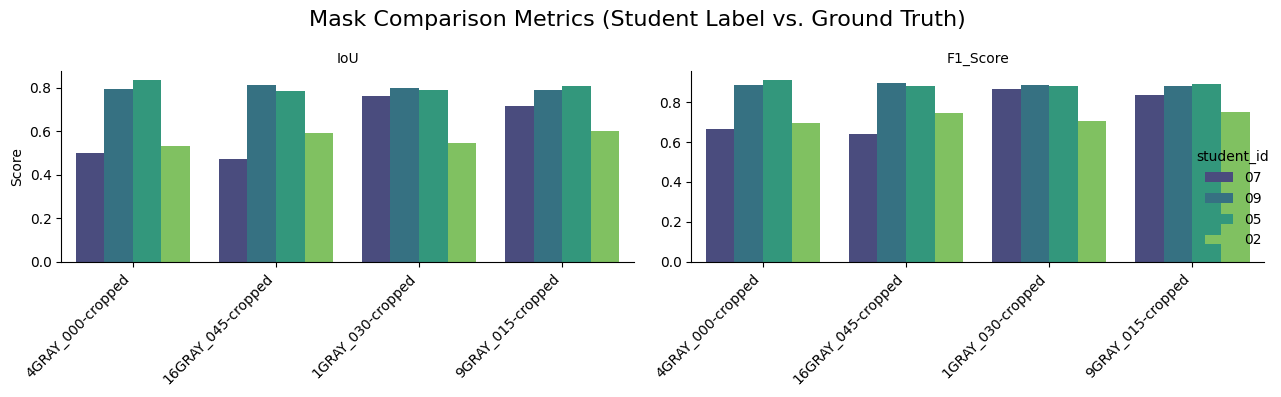

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the mask_comparison_df to long format for plotting
metrics_to_plot = ['IoU', 'F1_Score']
melted_metrics_df = mask_comparison_df.melt(
    id_vars=['original_filename', 'student_id'],
    value_vars=metrics_to_plot,
    var_name='Metric',
    value_name='Score'
)

# Use catplot for faceted bar plots
g = sns.catplot(
    data=melted_metrics_df,
    x='original_filename',
    y='Score',
    hue='student_id',
    col='Metric', # Facet by each metric
    col_wrap=2, # Two plots per row
    kind='bar',
    height=4, aspect=1.5,
    legend='auto',
    legend_out=True,
    palette='viridis',
    errorbar=None, # No error bars for single values
    sharey=False # Allow each facet to have its own y-axis scale
)

g.set_axis_labels("", "Score") # Remove x-axis label, it's rotated
g.set_titles(col_template="{col_name}") # Set title for each facet
g.set_xticklabels(rotation=45, ha='right')
g.fig.suptitle('Mask Comparison Metrics (Student Label vs. Ground Truth)', y=0.98, fontsize=16) # Overall title
#plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.tight_layout()
plt.savefig('mask_comparison_metrics.png')
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Ensure helper functions are available if this cell is run independently
# (These are assumed to be defined in previous cells like aX0gnYGTS_Vb)
# def load_and_binarize_mask(mask_path, target_size=None):
#     ...
# def calculate_mask_metrics(pred_mask, gt_mask):
#     ...

# --- Comparison: Union of all student labels vs. Ground Truth (Calibration Images) ---
print("\n--- Starting Union of ALL Student Calibration Labels vs. Ground Truth ---")
union_all_students_gt_comparison_results = []

grouped_calibration_by_image = calibration_comparison_df.groupby('original_filename')

for original_filename, group in grouped_calibration_by_image:
    student_label_mask_paths = group['label_map_full_path'].tolist()
    gt_mask_path = group['gt_mask_full_path'].iloc[0] # GT path is same for all entries of an original_filename

    gt_mask, gt_size = load_and_binarize_mask(gt_mask_path)
    if gt_mask is None:
        print(f"GT mask not found or failed to load for {original_filename}. Skipping union comparison.")
        continue

    # Initialize union mask with all False (empty mask) with the same dimensions as GT
    union_mask = np.full(gt_size, False, dtype=bool)
    valid_student_masks_found = False

    for path in student_label_mask_paths:
        student_mask, _ = load_and_binarize_mask(path, target_size=gt_size) # Resize to GT size
        if student_mask is not None:
            union_mask = np.logical_or(union_mask, student_mask) # Compute union
            valid_student_masks_found = True
        # else:
        #     print(f"Warning: Could not load student mask {path} for union calculation for image {original_filename}.")

    if not valid_student_masks_found:
        print(f"No valid student masks found for union calculation for image {original_filename}. Skipping.")
        continue

    metrics = calculate_mask_metrics(union_mask, gt_mask)
    union_all_students_gt_comparison_results.append({
        'original_filename': original_filename,
        'comparison_type': 'union_all_students_vs_gt',
        **metrics
    })

union_all_students_gt_comparison_df = pd.DataFrame(union_all_students_gt_comparison_results)

if not union_all_students_gt_comparison_df.empty:
    print("\nUnion of ALL Student Calibration Labels vs. Ground Truth Results (per image):")
    display(union_all_students_gt_comparison_df.head())
    print("\nSummary Statistics for Union of ALL Student Calibration Labels vs. Ground Truth:")
    display(union_all_students_gt_comparison_df[['IoU', 'F1_Score', 'Accuracy', 'Balanced_Accuracy']].describe())
else:
    print("\nNo union of ALL student calibration labels vs. ground truth comparison results generated.")


# --- Comparison: 80% Agreement of Students vs. Ground Truth (Calibration Images) ---
print("\n--- Starting 80% Agreement of Student Calibration Labels vs. Ground Truth ---")
agreement_80_gt_comparison_results = []

for original_filename, group in grouped_calibration_by_image:
    student_label_mask_paths = group['label_map_full_path'].tolist()
    gt_mask_path = group['gt_mask_full_path'].iloc[0]

    gt_mask, gt_size = load_and_binarize_mask(gt_mask_path)
    if gt_mask is None:
        print(f"GT mask not found or failed to load for {original_filename}. Skipping 80% agreement comparison.")
        continue

    loaded_student_masks = []
    for path in student_label_mask_paths:
        student_mask, _ = load_and_binarize_mask(path, target_size=gt_size)
        if student_mask is not None:
            loaded_student_masks.append(student_mask)

    if not loaded_student_masks:
        print(f"No valid student masks found for 80% agreement calculation for image {original_filename}. Skipping.")
        continue

    num_students = len(loaded_student_masks)
    # Stack all student masks into a 3D array (height, width, num_students)
    stacked_masks = np.stack(loaded_student_masks, axis=-1)

    # Count how many students marked each pixel as positive
    agreement_counts = np.sum(stacked_masks, axis=-1)

    # Define 80% agreement threshold
    threshold_80_percent = int(np.ceil(0.8 * num_students))

    # Create the 80% agreement mask
    agreement_80_mask = (agreement_counts >= threshold_80_percent).astype(bool)

    metrics = calculate_mask_metrics(agreement_80_mask, gt_mask)
    agreement_80_gt_comparison_results.append({
        'original_filename': original_filename,
        'comparison_type': '80_percent_agreement_vs_gt',
        'num_students_contributing': num_students,
        'agreement_threshold_count': threshold_80_percent,
        **metrics
    })

agreement_80_gt_comparison_df = pd.DataFrame(agreement_80_gt_comparison_results)

if not agreement_80_gt_comparison_df.empty:
    print("\n80% Agreement of Student Calibration Labels vs. Ground Truth Results (per image):")
    display(agreement_80_gt_comparison_df.head())
    print("\nSummary Statistics for 80% Agreement of Student Calibration Labels vs. Ground Truth:")
    display(agreement_80_gt_comparison_df[['IoU', 'F1_Score', 'Accuracy', 'Balanced_Accuracy']].describe())
else:
    print("\nNo 80% agreement of student calibration labels vs. ground truth comparison results generated.")


--- Starting Union of ALL Student Calibration Labels vs. Ground Truth ---

Union of ALL Student Calibration Labels vs. Ground Truth Results (per image):


,original_filename,comparison_type,IoU,F1_Score,Accuracy,Balanced_Accuracy,TP,TN,FP,FN
0,16GRAY_045-cropped,union_all_students_vs_gt,0.591506,0.743328,0.941771,0.968204,19024,193463,13138,0
1,1GRAY_030-cropped,union_all_students_vs_gt,0.545229,0.705693,0.936652,0.965722,17136,194196,14293,0
2,4GRAY_000-cropped,union_all_students_vs_gt,0.531896,0.694428,0.909943,0.949839,23088,182218,20319,0
3,9GRAY_015-cropped,union_all_students_vs_gt,0.597382,0.747951,0.928838,0.959994,23823,185746,16044,12



Summary Statistics for Union of ALL Student Calibration Labels vs. Ground Truth:


,IoU,F1_Score,Accuracy,Balanced_Accuracy
count,4.000000,4.000000,4.000000,4.000000
mean,0.566503,0.722850,0.929301,0.960940
std,0.032807,0.026781,0.013958,0.008160
min,0.531896,0.694428,0.909943,0.949839
25%,0.541896,0.702877,0.924114,0.957455
50%,0.568367,0.724511,0.932745,0.962858
75%,0.592975,0.744484,0.937931,0.966343
max,0.597382,0.747951,0.941771,0.968204



--- Starting 80% Agreement of Student Calibration Labels vs. Ground Truth ---

80% Agreement of Student Calibration Labels vs. Ground Truth Results (per image):


,original_filename,comparison_type,num_students_contributing,agreement_threshold_count,IoU,F1_Score,Accuracy,Balanced_Accuracy,TP,TN,FP,FN
0,16GRAY_045-cropped,80_percent_agreement_vs_gt,4,4,0.432008,0.603359,0.951960,0.716531,8244,206542,59,10780
1,1GRAY_030-cropped,80_percent_agreement_vs_gt,4,4,0.700162,0.823641,0.977015,0.852966,12110,208329,160,5026
2,4GRAY_000-cropped,80_percent_agreement_vs_gt,4,4,0.488114,0.656017,0.947320,0.745126,11334,202405,132,11754
3,9GRAY_015-cropped,80_percent_agreement_vs_gt,4,4,0.661735,0.796438,0.964131,0.831894,15832,201700,90,8003



Summary Statistics for 80% Agreement of Student Calibration Labels vs. Ground Truth:


,IoU,F1_Score,Accuracy,Balanced_Accuracy
count,4.000000,4.000000,4.000000,4.000000
mean,0.570504,0.719864,0.960106,0.786629
std,0.130516,0.106901,0.013316,0.066045
min,0.432008,0.603359,0.947320,0.716531
25%,0.474087,0.642852,0.950800,0.737977
50%,0.574924,0.726228,0.958045,0.788510
75%,0.671341,0.803239,0.967352,0.837162
max,0.700162,0.823641,0.977015,0.852966


### Visualization: Union of All Student Calibration Labels vs. Ground Truth

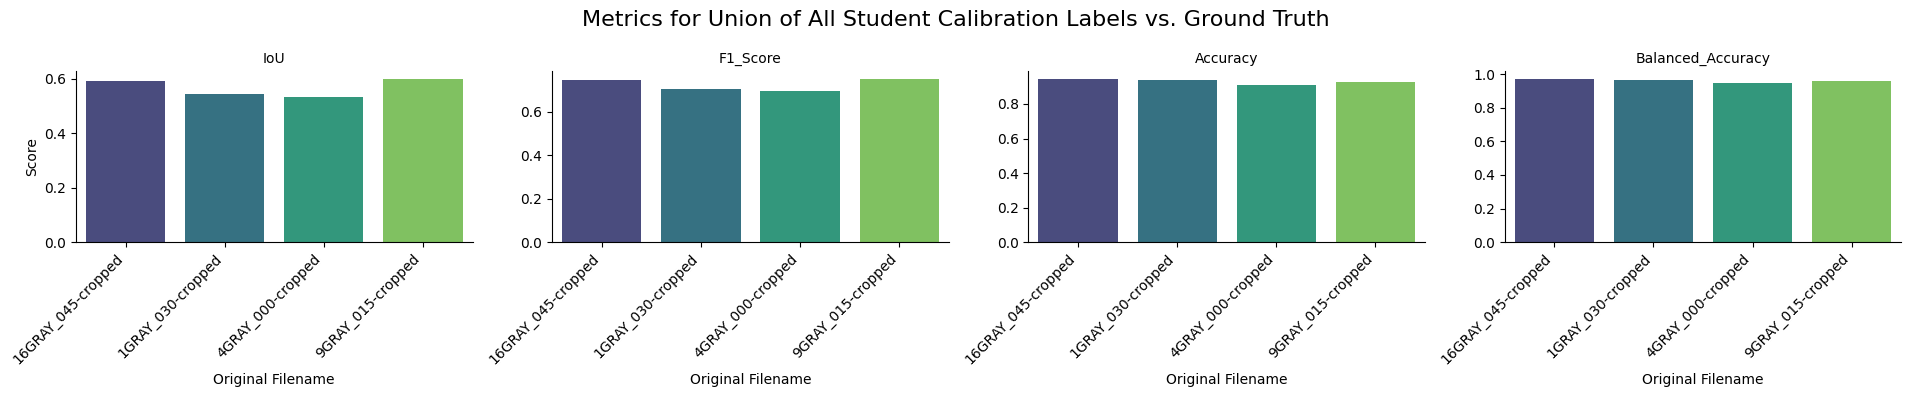

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if not union_all_students_gt_comparison_df.empty:
    metrics_to_plot = ['IoU', 'F1_Score', 'Accuracy', 'Balanced_Accuracy']
    melted_union_all_gt_comp_df = union_all_students_gt_comparison_df.melt(
        id_vars=['original_filename'],
        value_vars=metrics_to_plot,
        var_name='Metric',
        value_name='Score'
    )

    g = sns.catplot(
        data=melted_union_all_gt_comp_df,
        x='original_filename',
        y='Score',
        col='Metric',
        kind='bar',
        col_wrap=len(metrics_to_plot),
        height=4, aspect=1.2,
        hue='original_filename', # Assign x to hue as suggested by FutureWarning
        palette='viridis',
        legend='auto',
        legend_out=True,
        errorbar=None,
        sharey=False
    )
    g.set_axis_labels("Original Filename", "Score")
    g.set_titles(col_template="{col_name}")
    g.set_xticklabels(rotation=45, ha='right')
    g.fig.suptitle('Metrics for Union of All Student Calibration Labels vs. Ground Truth', y=0.98, fontsize=16)
    #g.fig.tight_layout(rect=[0, 0, 1, 0.98])
    plt.tight_layout()
    plt.savefig('union_of_all_students_vs_gt.png')
    plt.show()
else:
    print("\nNo data available for 'Union of All Student Calibration Labels vs. Ground Truth' visualization.")

### Visualization: 80% Agreement of Student Calibration Labels vs. Ground Truth

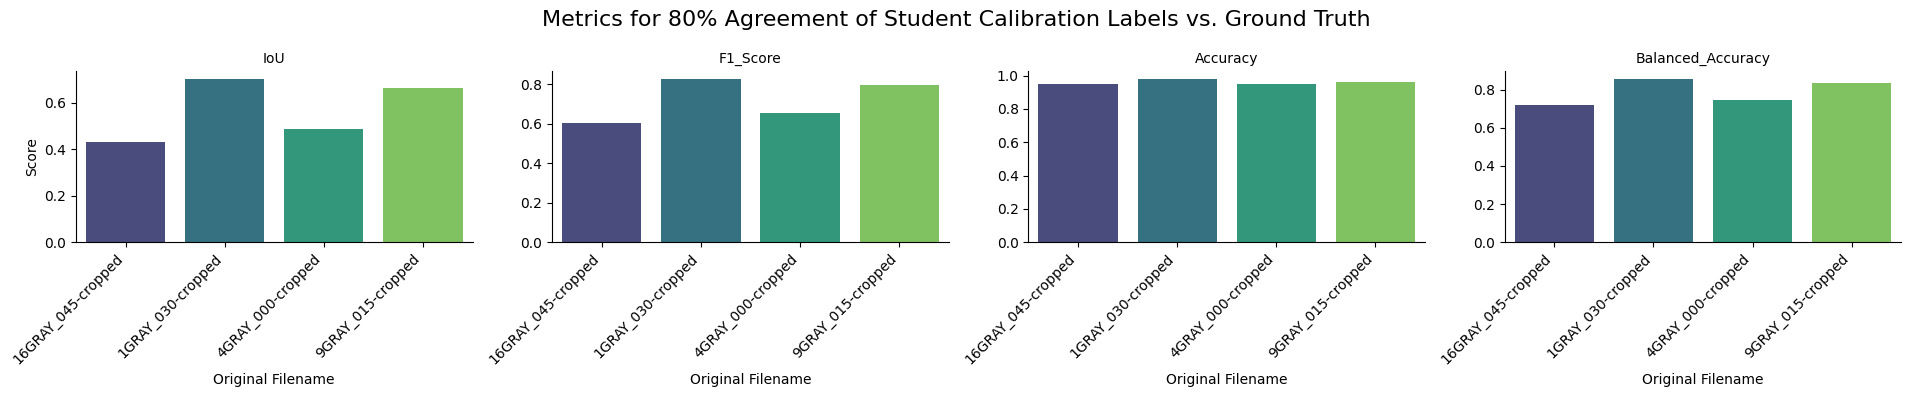

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if not agreement_80_gt_comparison_df.empty:
    metrics_to_plot = ['IoU', 'F1_Score', 'Accuracy', 'Balanced_Accuracy']
    melted_agreement_80_gt_comp_df = agreement_80_gt_comparison_df.melt(
        id_vars=['original_filename'],
        value_vars=metrics_to_plot,
        var_name='Metric',
        value_name='Score'
    )

    g = sns.catplot(
        data=melted_agreement_80_gt_comp_df,
        x='original_filename',
        y='Score',
        col='Metric',
        kind='bar',
        col_wrap=len(metrics_to_plot),
        height=4, aspect=1.2,
        hue='original_filename', # Assign x to hue as suggested by FutureWarning
        palette='viridis',
        legend='auto',
        legend_out=True,
        errorbar=None,
        sharey=False
    )
    g.set_axis_labels("Original Filename", "Score")
    g.set_titles(col_template="{col_name}")
    g.set_xticklabels(rotation=45, ha='right')
    g.fig.suptitle('Metrics for 80% Agreement of Student Calibration Labels vs. Ground Truth', y=0.98, fontsize=16)
    #g.fig.tight_layout(rect=[0, 0, 1, 0.98])
    plt.tight_layout()
    plt.savefig('80_percent_agreement_vs_gt.png')
    plt.show()
else:
    print("\nNo data available for '80% Agreement of Student Calibration Labels vs. Ground Truth' visualization.")

### Example Mask Visualizations


Visualizing masks for: 16GRAY_045-cropped


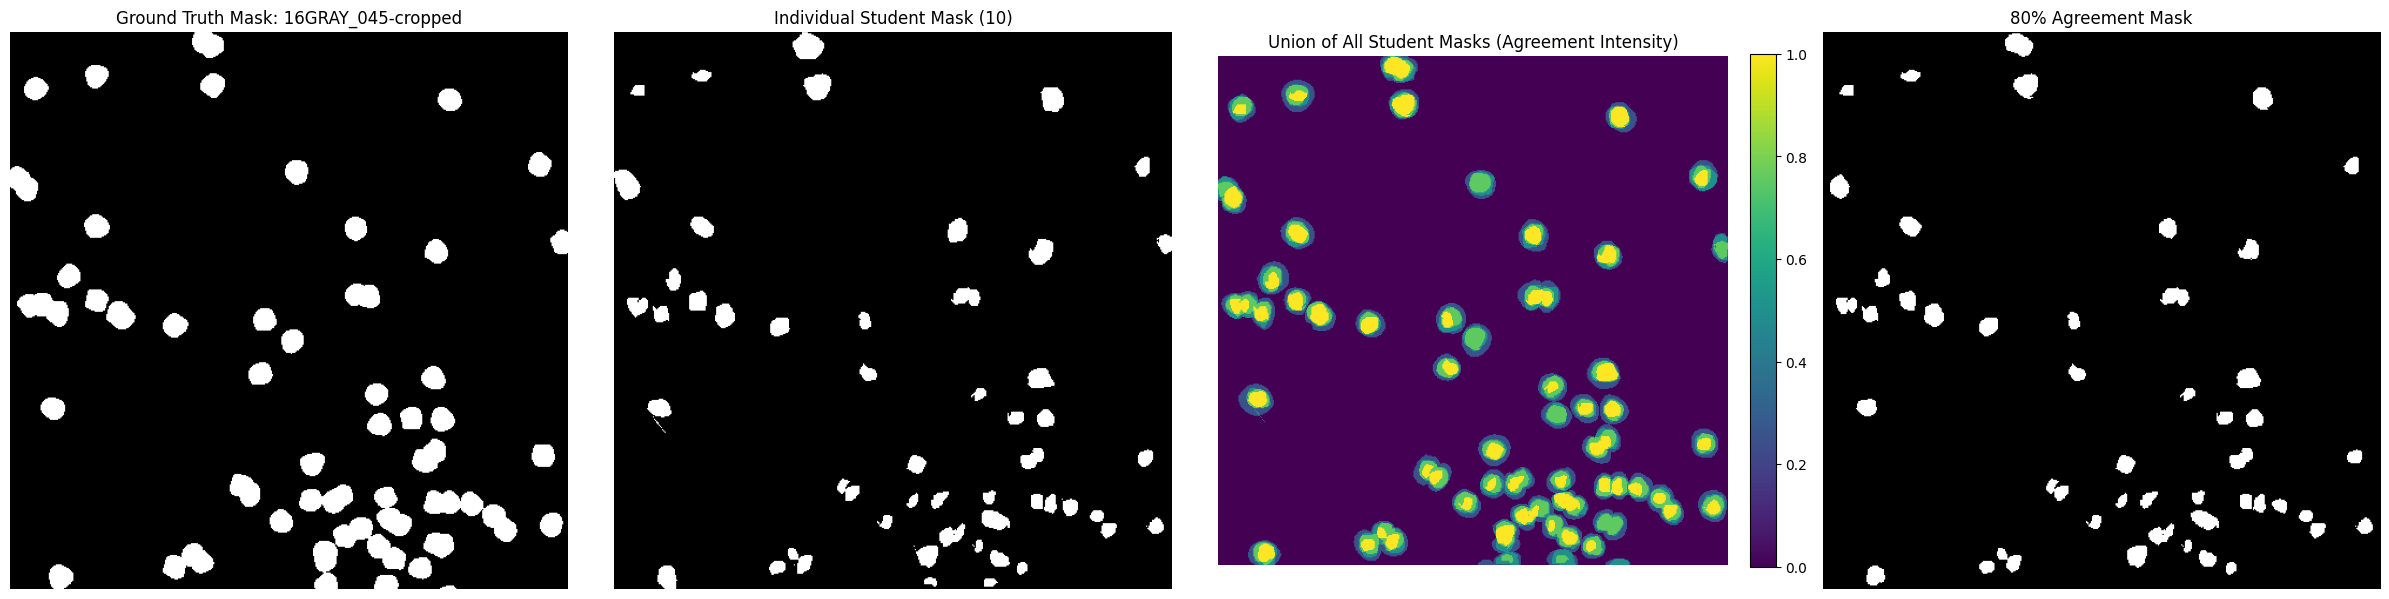


Visualizing masks for: 1GRAY_030-cropped


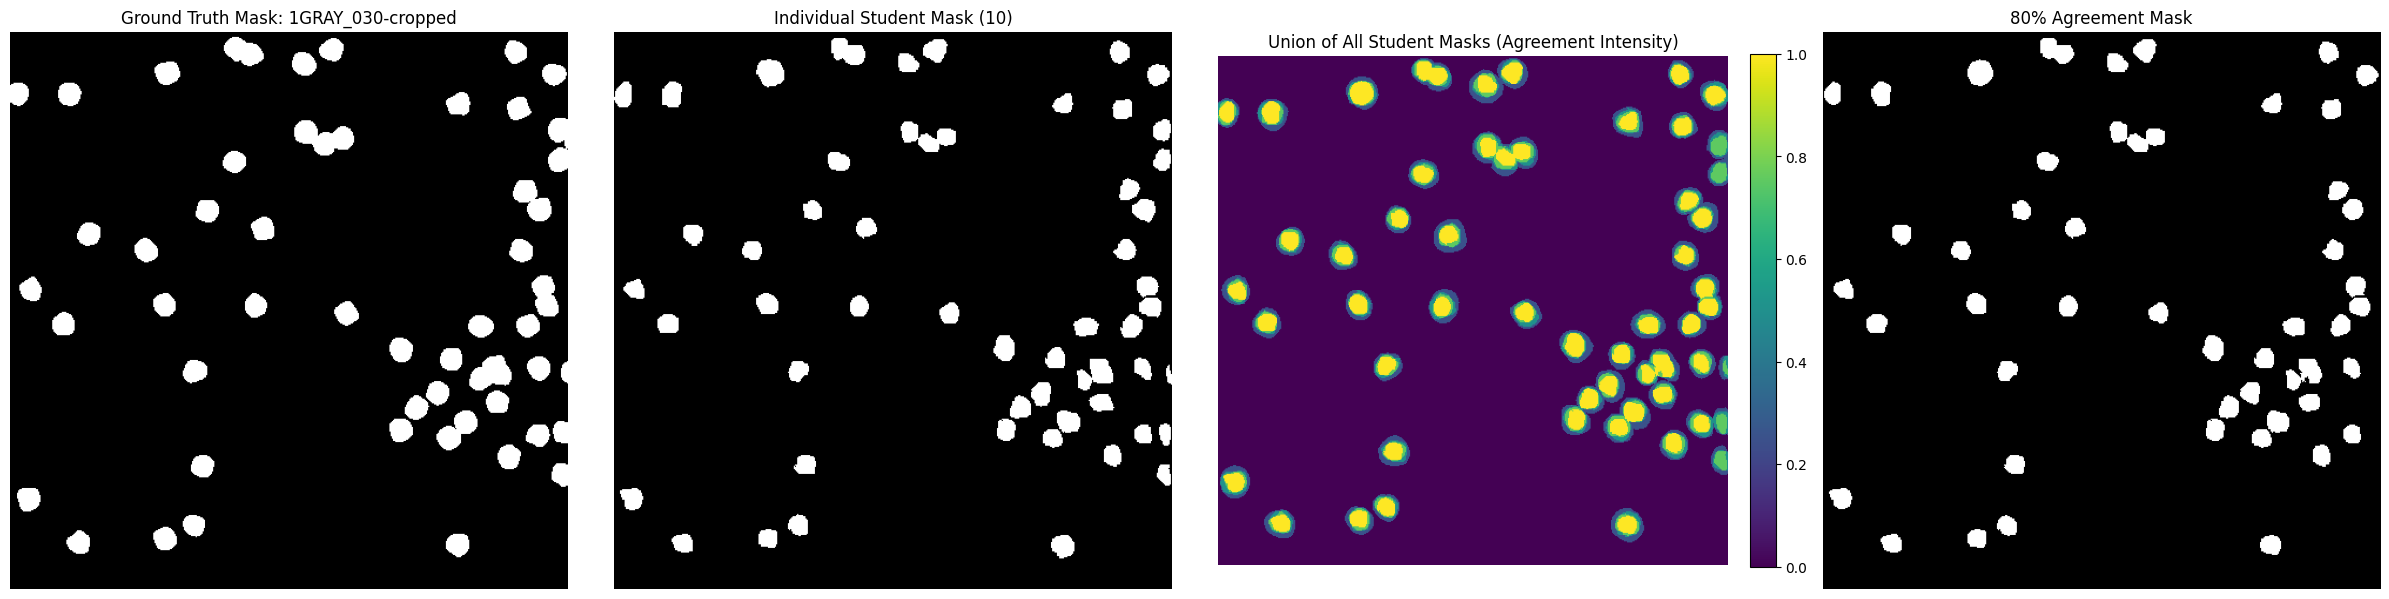


Visualizing masks for: 4GRAY_000-cropped


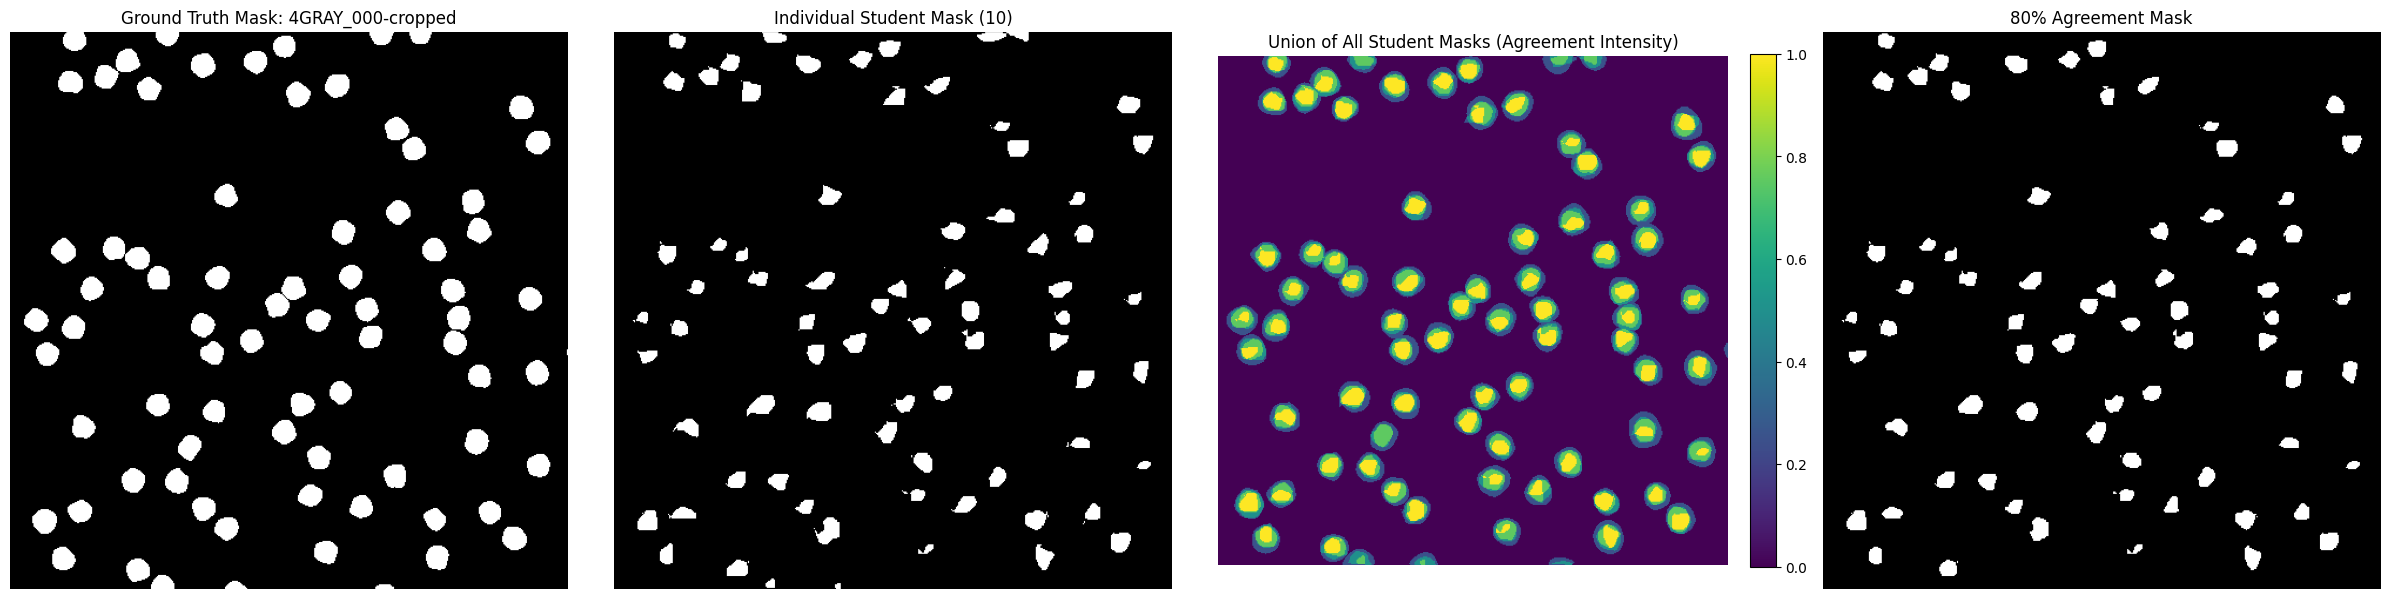


Visualizing masks for: 9GRAY_015-cropped


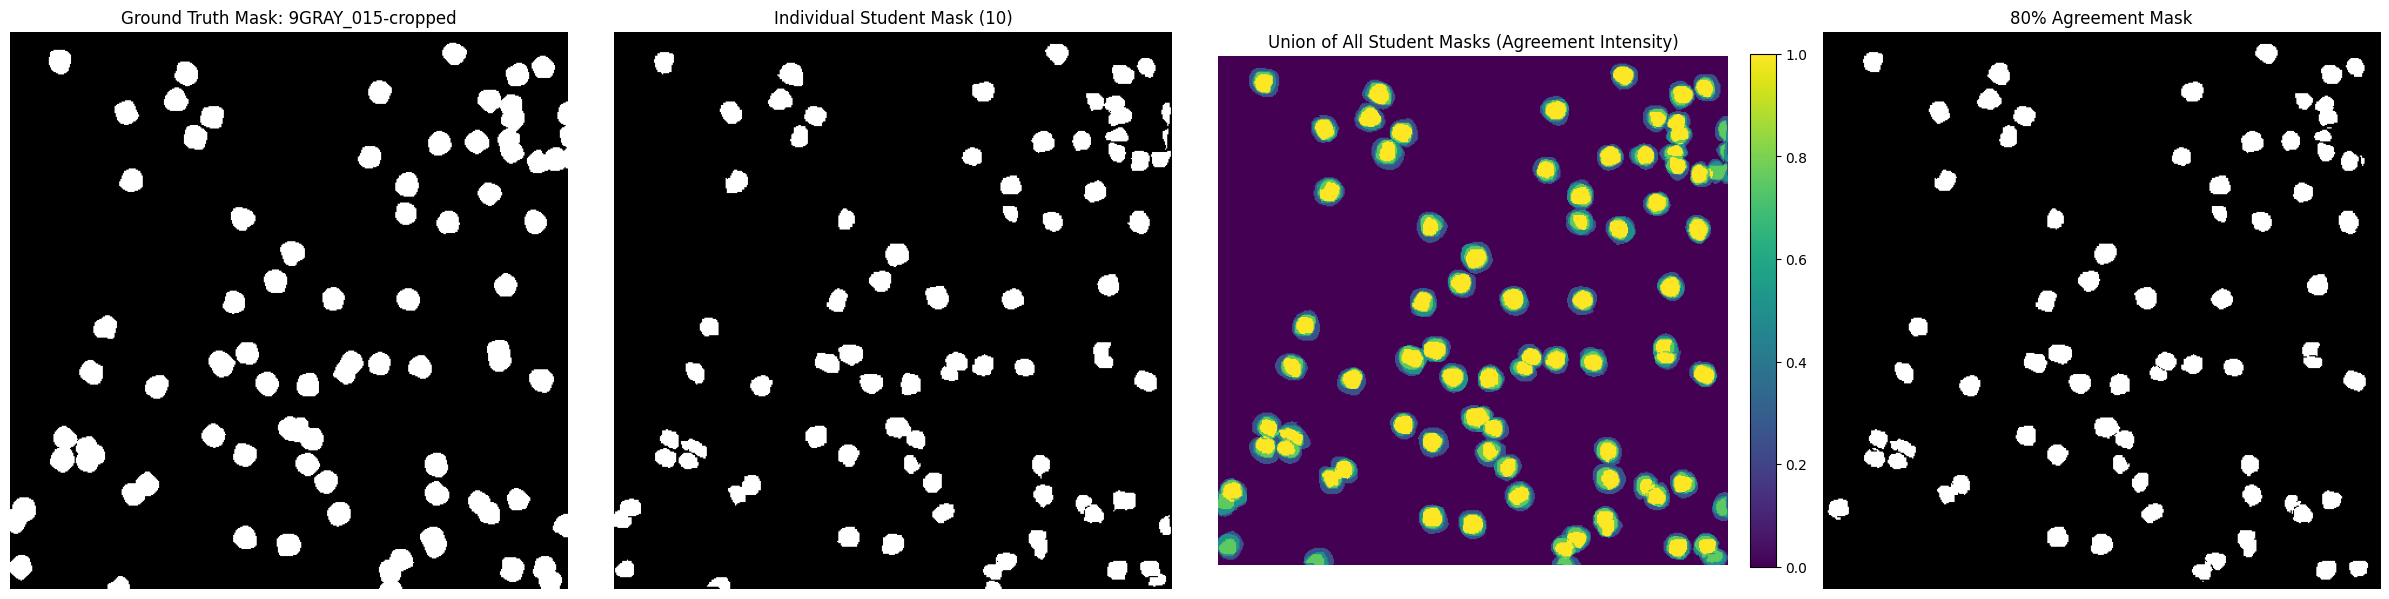

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

# Get all unique original_filenames from the calibration comparison results
if not union_all_students_gt_comparison_df.empty:
    calibration_filenames = union_all_students_gt_comparison_df['original_filename'].unique()

    for example_filename in calibration_filenames:
        print(f"\nVisualizing masks for: {example_filename}")
        example_group = calibration_comparison_df[calibration_comparison_df['original_filename'] == example_filename]

        if not example_group.empty:
            gt_mask_path = example_group['gt_mask_full_path'].iloc[0]

            # Load GT mask
            gt_mask, gt_size = load_and_binarize_mask(gt_mask_path)

            if gt_mask is not None:
                student_label_mask_paths = example_group['label_map_full_path'].tolist()
                loaded_student_masks_for_plotting = []

                # Load all student masks for this example, resizing to GT size
                for path in student_label_mask_paths:
                    student_mask, _ = load_and_binarize_mask(path, target_size=gt_size)
                    if student_mask is not None:
                        loaded_student_masks_for_plotting.append(student_mask)

                if not loaded_student_masks_for_plotting:
                    print(f"No valid student masks found for example {example_filename}.")
                else:
                    # Reconstruct union mask (sum of masks for colormap)
                    # Treat boolean masks as 0/1 integers for summing
                    summed_student_masks = np.sum(np.stack(loaded_student_masks_for_plotting, axis=-1).astype(int), axis=-1)/4

                    # Reconstruct 80% agreement mask
                    num_students_example = len(loaded_student_masks_for_plotting)
                    stacked_masks_example = np.stack(loaded_student_masks_for_plotting, axis=-1)
                    agreement_counts_example = np.sum(stacked_masks_example, axis=-1)
                    threshold_80_percent_example = int(np.ceil(0.8 * num_students_example))
                    agreement_80_mask_example = (agreement_counts_example >= threshold_80_percent_example).astype(bool)

                    # Select one individual student mask to display (e.g., the first one)
                    # Ensure there's a student_id for the first student mask to display
                    first_student_id = example_group['student_id'].iloc[0]
                    individual_student_mask_example = loaded_student_masks_for_plotting[0]

                    # Plotting
                    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

                    axes[0].imshow(gt_mask, cmap='gray')
                    axes[0].set_title(f'Ground Truth Mask: {example_filename}')
                    axes[0].axis('off')

                    axes[1].imshow(individual_student_mask_example, cmap='gray')
                    axes[1].set_title(f'Individual Student Mask ({first_student_id})')
                    axes[1].axis('off')

                    # Plot summed masks with a colormap and colorbar
                    img = axes[2].imshow(summed_student_masks, cmap='viridis') # Using 'hot' colormap
                    axes[2].set_title(f'Union of All Student Masks (Agreement Intensity)')
                    axes[2].axis('off')
                    fig.colorbar(img, ax=axes[2], orientation='vertical', fraction=0.046, pad=0.04)

                    axes[3].imshow(agreement_80_mask_example, cmap='gray')
                    axes[3].set_title(f'80% Agreement Mask')
                    axes[3].axis('off')

                    plt.tight_layout()
                    plt.savefig(f'example_masks_{example_filename}.png')
                    plt.show()
            else:
                print(f"Could not load GT mask for example {example_filename}.")
        else:
            print(f"No example group found for filename: {example_filename}.")
else:
    print("No data available in 'union_all_students_gt_comparison_df' to pick an example filename.")